In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

2026-02-26 14:00:10.028113: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 14:00:10.581371: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 14:00:14.110794: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# escolheu o fashion mnist por ser um dataset mais complexo
fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0 
print("x_train.shape:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train.shape: (60000, 28, 28)


In [4]:
# mais uma dimensão para o canal de cor
x_train = np.expand_dims(x_train, -1)# adicionando uma dimensão no final
x_test = np.expand_dims(x_test, -1)
print("x_train.shape:", x_train.shape)

x_train.shape: (60000, 28, 28, 1)


In [5]:
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [6]:
# Criando a CNN
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i) # filtro que reduzirá as imagens pela metade
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x) # aumento no número de filtros
x = Flatten()(x) # camada de planarização

# Camada densa
x = Dropout(0.2)(x) # dropout para evitar overfitting 
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x) #utilizamos a função softmax para a camada de saída

model = Model(i, x) # Criando o modelo

2026-02-26 14:03:43.692838: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
# compilando o modelo
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Treinamento
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15


2026-02-26 14:04:12.889738: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8074 - loss: 0.5171 - val_accuracy: 0.8550 - val_loss: 0.3895
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8663 - loss: 0.3570 - val_accuracy: 0.8772 - val_loss: 0.3267
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8834 - loss: 0.3105 - val_accuracy: 0.8832 - val_loss: 0.3175
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8948 - loss: 0.2783 - val_accuracy: 0.8880 - val_loss: 0.3013
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9055 - loss: 0.2510 - val_accuracy: 0.8900 - val_loss: 0.2946
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9127 - loss: 0.2306 - val_accuracy: 0.8957 - val_loss: 0.2904
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9204 - loss: 0.2127 - val_accuracy: 0.8966 - val_loss: 0.2887
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9261 - loss: 0.1941 - val

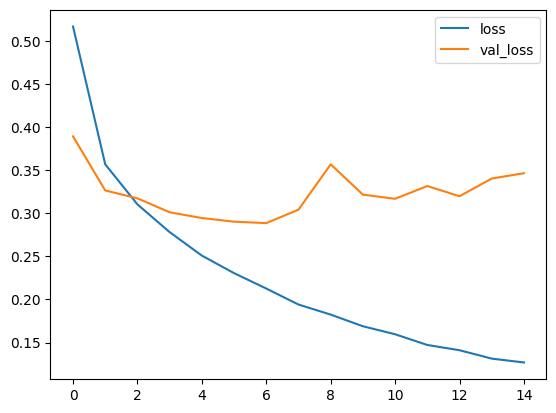

In [9]:
# resultados do treinamento
plt.plot(r.history['loss'], label='loss') # erros durante o treinamento
plt.plot(r.history['val_loss'], label='val_loss') # erros de validação
plt.legend()

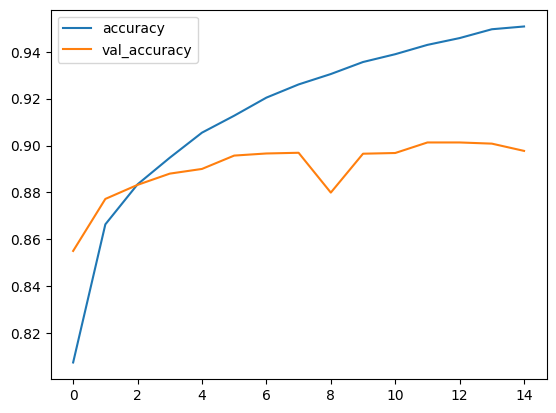

In [10]:
# acurácia do modelo
plt.plot(r.history['accuracy'], label='accuracy') # por época
plt.plot(r.history['val_accuracy'], label='val_accuracy') # validação por época
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Confusion matrix, without normalization
[[837   1  28   9   4   1 114   0   6   0]
 [  2 974   0  12   3   0   7   0   2   0]
 [ 12   2 845   9  65   0  67   0   0   0]
 [ 29   3  22 871  37   0  36   0   2   0]
 [  0   1  48  22 862   0  65   0   2   0]
 [  1   0   0   0   0 970   0  21   2   6]
 [ 88   1  67  17  98   0 717   0  12   0]
 [  0   0   0   0   0   6   0 985   1   8]
 [  1   0   4   2   5   1   7   2 978   0]
 [  0   0   0   0   0   6   1  55   0 938]]


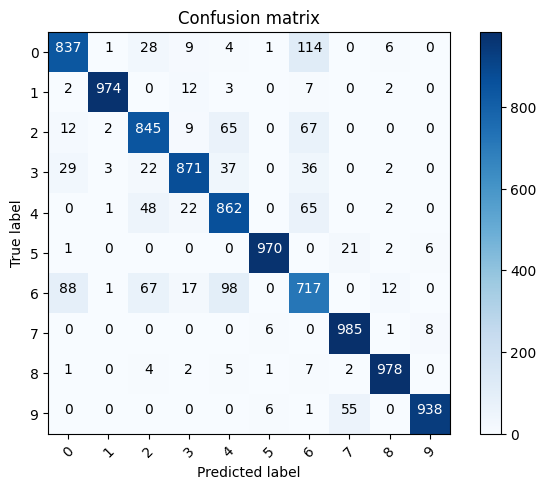

In [11]:
# matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, 
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix', 
                          cmap=plt.cm.Blues # Cor
                          ):
    # normalização da matriz
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)
    
    # plotagem da matriz de confusão
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x 
    plt.yticks(tick_marks, classes) # rotulos do eixo y
    
    # formatação dos números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2. # limiar para a cor do texto
    
    # adicionando texto na matriz de confusão
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')
    
    # adicionando rótulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# predição
p_test = model.predict(x_test).argmax(axis=1)
# gerando a matriz
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [12]:
labels = '''T-shirt/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split()

Text(0.5, 1.0, 'True label: Shirt Predicted: T-shirt/top')

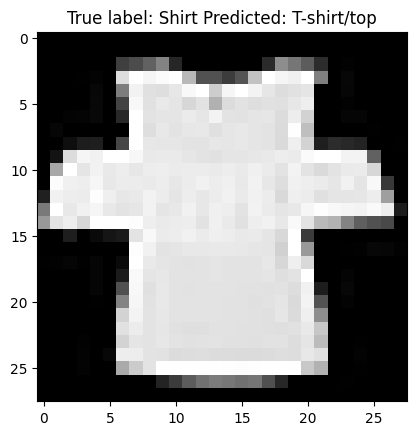

In [13]:
# mostrando a incoreta
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]))